In [1]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# change the directory below to be able to read the data at your end 
dft = pd.read_csv(r"C:\Users\Dell\Documents\my_linux\repos_\asset_financing_risk_prediction\asset_financing\data\raw\application_train.csv")

In [3]:
# general info about dataset
display(dft.shape, dft.info(), dft.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


(307511, 122)

None

0

In [4]:
list(dft.columns)

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

#### Identify missing values, outliers, and class distribution.

In [5]:
dfta = dft[['SK_ID_CURR','TARGET','CODE_GENDER','FLAG_OWN_CAR','AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY',\
            'NAME_INCOME_TYPE','NAME_EDUCATION_TYPE',\
            'FLAG_PHONE','CNT_FAM_MEMBERS','REG_CITY_NOT_LIVE_CITY',\
            'AMT_REQ_CREDIT_BUREAU_MON','AMT_REQ_CREDIT_BUREAU_QRT']]
dfta.sample(5)

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,FLAG_PHONE,CNT_FAM_MEMBERS,REG_CITY_NOT_LIVE_CITY,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT
218191,352792,0,M,Y,153000.0,276903.0,25524.0,Working,Secondary / secondary special,1,3.0,0,0.0,0.0
56503,165469,0,M,N,171000.0,288873.0,17802.0,Pensioner,Secondary / secondary special,0,2.0,0,0.0,0.0
43006,149788,0,F,Y,157500.0,360000.0,19530.0,Working,Higher education,1,2.0,0,0.0,0.0
287817,433407,0,F,Y,135000.0,591336.0,15727.5,Working,Secondary / secondary special,0,3.0,0,0.0,1.0
281923,426556,0,M,N,157500.0,499261.5,23404.5,Working,Higher education,0,2.0,0,NaN,NaN


In [6]:
# check for missing values
dfta.isna().sum()

SK_ID_CURR                       0
TARGET                           0
CODE_GENDER                      0
FLAG_OWN_CAR                     0
AMT_INCOME_TOTAL                 0
AMT_CREDIT                       0
AMT_ANNUITY                     12
NAME_INCOME_TYPE                 0
NAME_EDUCATION_TYPE              0
FLAG_PHONE                       0
CNT_FAM_MEMBERS                  2
REG_CITY_NOT_LIVE_CITY           0
AMT_REQ_CREDIT_BUREAU_MON    41519
AMT_REQ_CREDIT_BUREAU_QRT    41519
dtype: int64

In [7]:
dfta["AMT_REQ_CREDIT_BUREAU_MON"] = dfta["AMT_REQ_CREDIT_BUREAU_MON"].fillna(dfta["AMT_REQ_CREDIT_BUREAU_MON"].median())
dfta["AMT_REQ_CREDIT_BUREAU_QRT"] = dfta["AMT_REQ_CREDIT_BUREAU_QRT"].fillna(dfta["AMT_REQ_CREDIT_BUREAU_QRT"].median())

C:\Users\Dell\AppData\Local\Temp\ipykernel_7776\2316345651.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfta["AMT_REQ_CREDIT_BUREAU_MON"] = dfta["AMT_REQ_CREDIT_BUREAU_MON"].fillna(dfta["AMT_REQ_CREDIT_BUREAU_MON"].median())
C:\Users\Dell\AppData\Local\Temp\ipykernel_7776\2316345651.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfta["AMT_REQ_CREDIT_BUREAU_QRT"] = dfta["AMT_REQ_CREDIT_BUREAU_QRT"].fillna(dfta["AMT_REQ_CREDIT_BUREAU_QRT"].median())


In [8]:
# summary of missing values and general information
display(dfta.isna().sum(), dfta.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   SK_ID_CURR                 307511 non-null  int64  
 1   TARGET                     307511 non-null  int64  
 2   CODE_GENDER                307511 non-null  object 
 3   FLAG_OWN_CAR               307511 non-null  object 
 4   AMT_INCOME_TOTAL           307511 non-null  float64
 5   AMT_CREDIT                 307511 non-null  float64
 6   AMT_ANNUITY                307499 non-null  float64
 7   NAME_INCOME_TYPE           307511 non-null  object 
 8   NAME_EDUCATION_TYPE        307511 non-null  object 
 9   FLAG_PHONE                 307511 non-null  int64  
 10  CNT_FAM_MEMBERS            307509 non-null  float64
 11  REG_CITY_NOT_LIVE_CITY     307511 non-null  int64  
 12  AMT_REQ_CREDIT_BUREAU_MON  307511 non-null  float64
 13  AMT_REQ_CREDIT_BUREAU_QRT  30

SK_ID_CURR                    0
TARGET                        0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
AMT_INCOME_TOTAL              0
AMT_CREDIT                    0
AMT_ANNUITY                  12
NAME_INCOME_TYPE              0
NAME_EDUCATION_TYPE           0
FLAG_PHONE                    0
CNT_FAM_MEMBERS               2
REG_CITY_NOT_LIVE_CITY        0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
dtype: int64

None

In [9]:
# statistical description for categorical features 
dfta.describe(exclude='number')

,CODE_GENDER,FLAG_OWN_CAR,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE
count,307511,307511,307511,307511
unique,3,2,8,5
top,F,N,Working,Secondary / secondary special
freq,202448,202924,158774,218391


In [10]:
# descriptive statistics for numerical features
dfta.describe(exclude='object') 

,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,FLAG_PHONE,CNT_FAM_MEMBERS,REG_CITY_NOT_LIVE_CITY,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT
count,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000
mean,278180.518577,0.080729,1.687979e+05,5.990260e+05,27108.573909,0.281066,2.152665,0.078173,0.231293,0.229631
std,102790.175348,0.272419,2.371231e+05,4.024908e+05,14493.737315,0.449521,0.910682,0.268444,0.856810,0.744059
min,100002.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,1.125000e+05,2.700000e+05,16524.000000,0.000000,2.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,0.000000,2.000000,0.000000,0.000000,0.000000
75%,367142.500000,0.000000,2.025000e+05,8.086500e+05,34596.000000,1.000000,3.000000,0.000000,0.000000,0.000000
max,456255.000000,1.000000,1.170000e+08,4.050000e+06,258025.500000,1.000000,20.000000,1.000000,27.000000,261.000000


In [11]:
# outlier detection for:
# Detect Outlier - AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY
def detect_outliers_iqr(df, columns, return_all_outliers=True, flag_outliers=False):
    df_out = df.copy()
    outlier_indices = set()
    outlier_dict = {}

    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Boolean mask for outliers
        mask = (df[column] < lower_bound) | (df[column] > upper_bound)
        # Store outlier indices for this column
        outlier_dict[column] = df[mask]
        if flag_outliers:
            flag_col_name = f'{column}_outlier_flag'
            df_out[flag_col_name] = mask.astype(int)

        if return_all_outliers:
            outlier_indices.update(df[mask].index)
    if return_all_outliers:
        return df_out.loc[list(outlier_indices)]
    elif flag_outliers:
        return df_out
    else:
        return outlier_dict

In [12]:
# detection of outliers
outliers_per_column = detect_outliers_iqr(dfta, ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"], return_all_outliers=False)
print("\nOutliers per column:")
for col, outliers in outliers_per_column.items():
    print(f"\n{col}:\n{outliers}")


Outliers per column:

AMT_INCOME_TOTAL:
        SK_ID_CURR  TARGET CODE_GENDER FLAG_OWN_CAR  AMT_INCOME_TOTAL  \
7           100010       0           M            Y          360000.0   
22          100026       0           F            N          450000.0   
33          100039       0           M            Y          360000.0   
49          100056       0           M            Y          360000.0   
51          100059       0           M            Y          540000.0   
...            ...     ...         ...          ...               ...   
307460      456199       0           M            Y          382500.0   
307477      456217       0           F            N          360000.0   
307484      456228       0           F            Y          540000.0   
307492      456236       0           M            Y          585000.0   
307496      456240       0           F            N          360000.0   

        AMT_CREDIT  AMT_ANNUITY      NAME_INCOME_TYPE  \
7        1530000.0      4

In [13]:
# Handle outliers
def replace_outliers_with_median(df, columns):
    df_out = df.copy()
    for column in columns:
        Q1 = df_out[column].quantile(0.25)
        Q3 = df_out[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        median = df_out[column].median()

        # Replace outliers with median
        df_out[column] = df_out[column].apply(
            lambda x: median if (x < lower_bound or x > upper_bound) else x
        )
    return df_out

In [14]:
# Replace outliers with median
df_clean = replace_outliers_with_median(dfta, ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"])

In [15]:
# check for duplicate entry
df_clean.duplicated().sum()

0

In [16]:
df_clean.duplicated().sum()

0

In [19]:
# drop duplicate entry
#df_clean.drop_duplicates(inplace=True)

In [17]:
# class distribution
df_clean['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

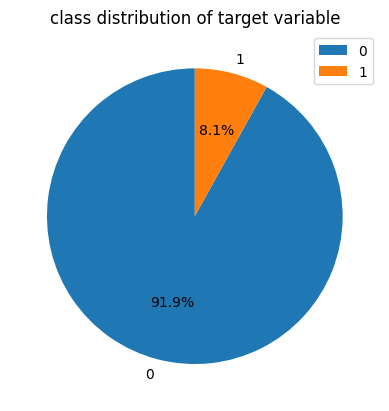

In [18]:
# 
counts = df_clean['TARGET'].value_counts()
labels = counts.index
sizes = counts.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("class distribution of target variable")
plt.legend()
plt.show()

#### Summarize dataset structure and key statistics.

In [19]:
# correct the datatype
df_clean["TARGET"] = df_clean["TARGET"].astype('str')
df_clean["REG_CITY_NOT_LIVE_CITY"] = df_clean["REG_CITY_NOT_LIVE_CITY"].astype('boolean')
df_clean["FLAG_OWN_CAR"] = df_clean["FLAG_OWN_CAR"].astype('str')
df_clean["FLAG_PHONE"] = df_clean["FLAG_PHONE"].astype('boolean')

In [20]:
# dataset summary
df_clean.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   SK_ID_CURR                 307511 non-null  int64  
 1   TARGET                     307511 non-null  object 
 2   CODE_GENDER                307511 non-null  object 
 3   FLAG_OWN_CAR               307511 non-null  object 
 4   AMT_INCOME_TOTAL           307511 non-null  float64
 5   AMT_CREDIT                 307511 non-null  float64
 6   AMT_ANNUITY                307499 non-null  float64
 7   NAME_INCOME_TYPE           307511 non-null  object 
 8   NAME_EDUCATION_TYPE        307511 non-null  object 
 9   FLAG_PHONE                 307511 non-null  boolean
 10  CNT_FAM_MEMBERS            307509 non-null  float64
 11  REG_CITY_NOT_LIVE_CITY     307511 non-null  boolean
 12  AMT_REQ_CREDIT_BUREAU_MON  307511 non-null  float64
 13  AMT_REQ_CREDIT_BUREAU_QRT  30

In [21]:
df_clean.to_csv(r"C:\Users\Dell\Documents\my_linux\repos_\asset_financing_risk_prediction\asset_financing\data\processed\clean.csv", index=False)